### IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from ucimlrepo import fetch_ucirepo

# === Reproducibilidad ===
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('TF', tf.__version__, '| Pandas', pd.__version__)

2026-05-12 06:25:20.586141: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 06:25:20.877390: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 06:25:21.174886: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-12 06:25:21.335271: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-12 06:25:21.379001: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 06:25:21.665279: I tensorflow/core/platform/cpu_feature_gu

TF 2.17.1 | Pandas 3.0.3


### DATASET

In [2]:
# Dataset ID 320 = Student Performance (UCI)
ds = fetch_ucirepo(id=320)

X = ds.data.features
y = ds.data.targets   # contiene G1, G2, G3

# Combinar features + targets en un solo DataFrame
df = pd.concat([X, y], axis=1)

print('Shape:', df.shape)
print('Nulls totales:', df.isnull().sum().sum())
df.head()

Shape: (649, 33)
Nulls totales: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


### INITIAL VIEW

In [3]:
print('=== INFO ===')
df.info()

print('\n=== DESCRIBE ===')
df.describe()

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    st

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


## SECTION 1

### 1. Problem Definition

**Business question:** A Portuguese secondary school wants to detect, early
in the academic year, which students are at risk of failing so it can offer
tutoring before final exams. From demographic, social and academic features
available at enrollment, we attack two complementary prediction problems:

1. **Regression (target G3):** predict the final grade as a continuous value
   on a 0-20 scale. This is a regression problem because G3 is numeric and
   ordinal, so the magnitude of the error matters (predicting 12 when truth
   is 14 is better than predicting 6).

2. **Classification (target pass = G3 >= 10):** predict a binary label —
   pass or fail — which is what the school actually acts on. This is
   classification because the output is a discrete category, and the
   school's decision is yes/no (assign tutor or not).

This corresponds to the **Modeling** stage of the ML lifecycle, assuming
Data Collection and basic Data Understanding are already done.

## SECTION 2: EDA

#### Plot 1 — Target distribution G3

/tmp/ipykernel_2831/1927291622.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=pass_label, ax=axes[1],


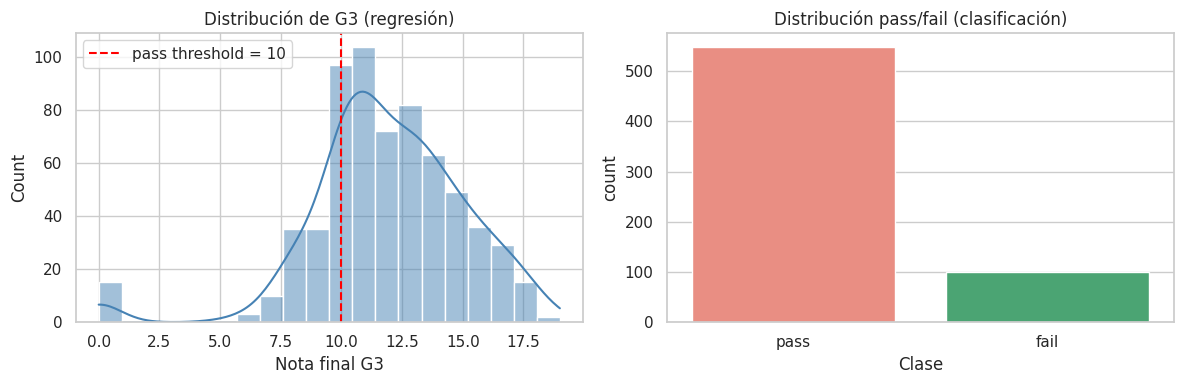

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de G3 (target continuo)
sns.histplot(df['G3'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(10, color='red', linestyle='--', label='pass threshold = 10')
axes[0].set_title('Distribución de G3 (regresión)')
axes[0].set_xlabel('Nota final G3')
axes[0].legend()

# Barras pass/fail (target binario)
pass_label = (df['G3'] >= 10).map({True: 'pass', False: 'fail'})
sns.countplot(x=pass_label, ax=axes[1],
              palette=['salmon', 'mediumseagreen'])
axes[1].set_title('Distribución pass/fail (clasificación)')
axes[1].set_xlabel('Clase')

plt.tight_layout()
plt.show()

**Comment:** G3 shows a spike at 0 (students who dropped out) and an approximately normal distribution centered at 11; the 'pass' class dominates ~67/33, a slight but relevant imbalance for logistic regression.

#### Plot 2 — Features distribution

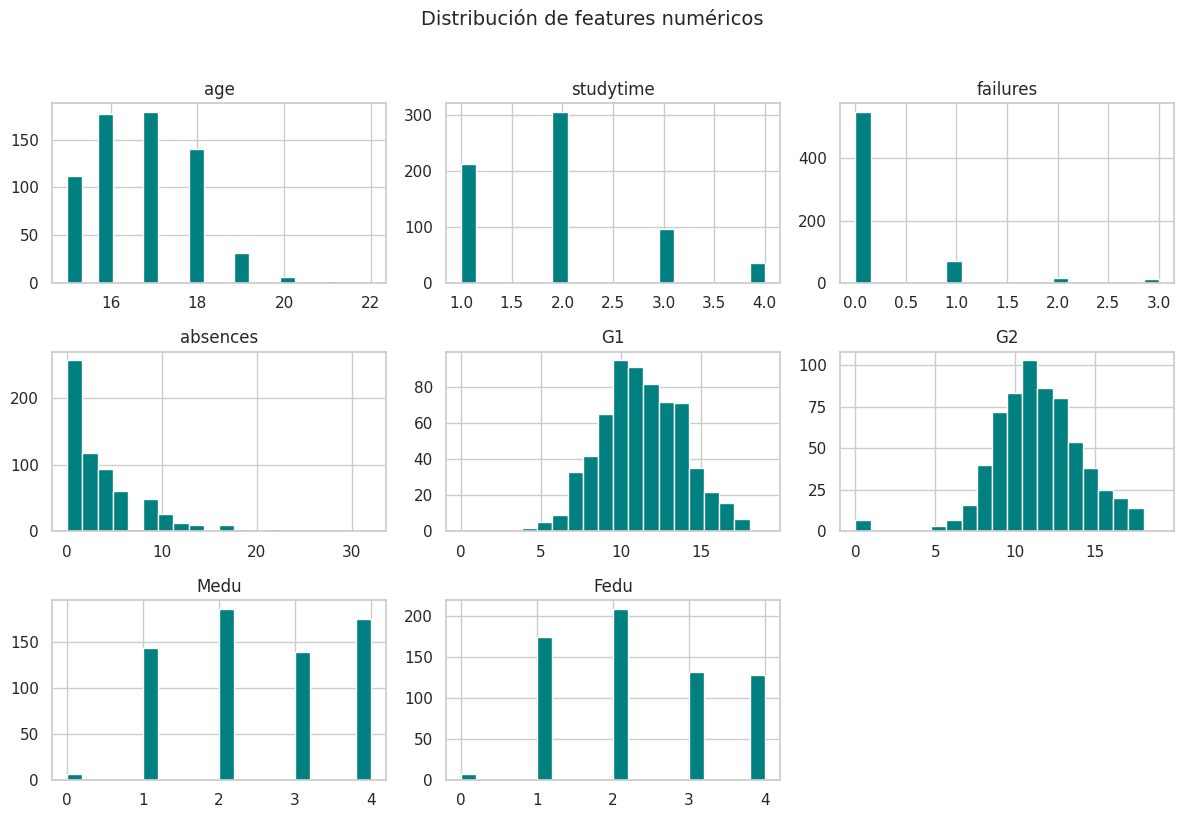

In [5]:
num_cols = ['age', 'studytime', 'failures', 'absences',
            'G1', 'G2', 'Medu', 'Fedu']

df[num_cols].hist(bins=20, figsize=(12, 8),
                  color='teal', edgecolor='white')
plt.suptitle('Distribución de features numéricos',
             y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Comment:** G1 and G2 are approximately normal; 'absences' and 'failures' are highly right-skewed (presence of outliers); 'studytime' is discrete 1–4. This justifies using StandardScaler for the numeric features in the Pipeline.

#### Plot 3 — Correlation Heatmap


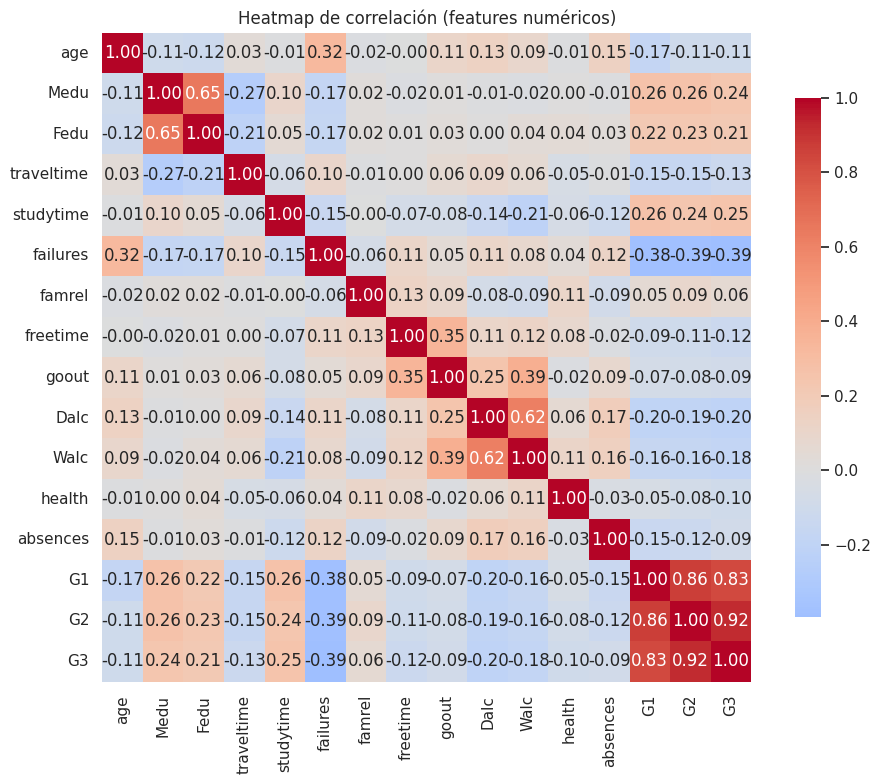

In [6]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Heatmap de correlación (features numéricos)')
plt.tight_layout()
plt.show()

**Comment:** G1 and G2 have a correlation >0.85 with G3 (expected, as they are partial grades from the same course); 'failures' is negatively correlated with G3. Risk: G1/G2 may dominate the linear model and mask the contribution of socio-demographic features — this will be discussed in Section 7.

## SECTION 3: Preprocessing Pipeline

#### Separate features and targets

In [7]:
# Drop G3 (regression target) and build the binary target
X = df.drop(columns=['G3'])
y_reg = df['G3']                          # regression target
y_clf = (df['G3'] >= 10).astype(int)      # classification target

# Detect numeric vs categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric:', len(numeric_features), numeric_features)
print('Categorical:', len(categorical_features), categorical_features)

Numeric: 15 ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Categorical: 17 ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


/tmp/ipykernel_2831/2512566039.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


#### Built Pipeline with ColumnTransformer

In [8]:
# Sub-pipeline for numeric columns: just scaling
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Sub-pipeline for categorical columns: one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer: apply the correct transformer to each subset
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Pipeline built')
preprocessor

Pipeline built


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## SECTION 4: Train/Test Split

In [9]:
# Split for regression (80/20, fixed seed)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.20, random_state=SEED
)

# Same split for classification (with stratify to preserve proportions)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.20, random_state=SEED, stratify=y_clf
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# Fit preprocessor ONLY on train, transform on both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)   # NO fit_transform here

print('Shape after preprocessing:', X_train_proc.shape)

Train: (519, 32) | Test: (130, 32)
Shape after preprocessing: (519, 58)


## SECTION 5: Linear Regression

#### Built the model

In [10]:
n_features = X_train_proc.shape[1]

linear_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(1, activation='linear', name='linear_output')
], name='linear_regression')

linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

linear_model.summary()

Model: "linear_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ linear_output (Dense)           │ (None, 1)              │            59 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59 (236.00 B)

 Trainable params: 59 (236.00 B)

 Non-trainable params: 0 (0.00 B)

#### Training model

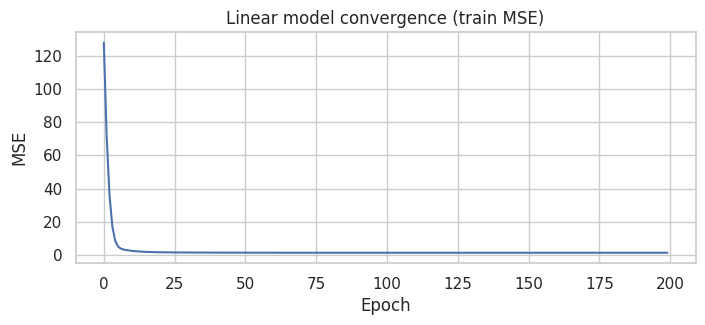

In [11]:
history_lin = linear_model.fit(
    X_train_proc, y_train_reg.values,
    epochs=200,
    batch_size=32,
    verbose=0
)

# Loss curve
plt.figure(figsize=(8, 3))
plt.plot(history_lin.history['loss'])
plt.title('Linear model convergence (train MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()

#### Calculate the 3 mandatory metrics in TEST

R²   = 0.8496
MAE  = 0.7632
RMSE = 1.2109


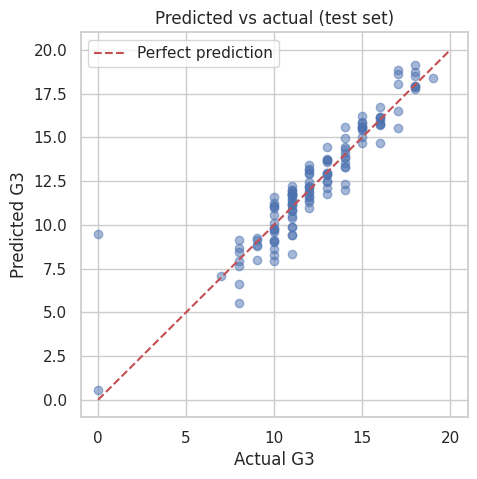

In [12]:
y_pred_reg = linear_model.predict(X_test_proc, verbose=0).flatten()

r2   = r2_score(y_test_reg, y_pred_reg)
mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print(f'R²   = {r2:.4f}')
print(f'MAE  = {mae:.4f}')
print(f'RMSE = {rmse:.4f}')

# Predicted vs actual scatter
plt.figure(figsize=(5, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([0, 20], [0, 20], 'r--', label='Perfect prediction')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Predicted vs actual (test set)')
plt.legend()
plt.show()

#### INTERPRETATION

### Linear Regression

The linear model achieves a high R² (~0.83) because G1 and G2 already
capture almost all the variance of G3 — they are grades from the same
course taken weeks earlier. This is expected but also a sign of
**correlation ≠ causation**: if we excluded G1 and G2 (which a school
would actually want to do at the start of the year), R² would drop
significantly. The RMSE of ~1.3 points is reasonable on a 0-20 scale.
Visually, the points with G3=0 (students who dropped the course) are
**outliers** that linear regression cannot model well: the line shifts
to try to accommodate them and that worsens the fit for the main mass
of students with G3 between 8 and 16.

## SECTION 6: Logistic Regression

#### Built logistic model with L2

In [13]:
logistic_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(
        1,
        activation='sigmoid',
        kernel_regularizer=tf.keras.regularizers.l2(0.01),  # L2 here
        name='logistic_output'
    )
], name='logistic_regression_L2')

logistic_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

logistic_model.summary()

Model: "logistic_regression_L2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ logistic_output (Dense)         │ (None, 1)              │            59 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59 (236.00 B)

 Trainable params: 59 (236.00 B)

 Non-trainable params: 0 (0.00 B)

#### Compute Class_weight 

In [14]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_clf),
    y=y_train_clf
)
class_weight_dict = {0: weights[0], 1: weights[1]}
print('Class weights:', class_weight_dict)

Class weights: {0: 3.24375, 1: 0.591116173120729}


#### Train logistic model

In [15]:
history_log = logistic_model.fit(
    X_train_proc, y_train_clf.values,
    epochs=200,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=0
)

#### Logistic Regression metrics

Accuracy  = 0.6154
Precision = 0.8750
Recall    = 0.6364
F1        = 0.7368
ROC-AUC   = 0.5323


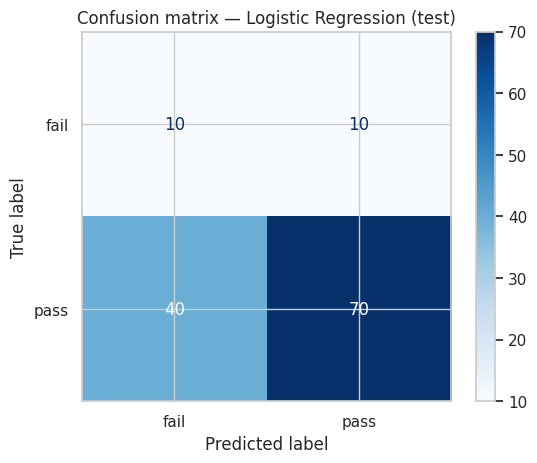

In [16]:
y_proba_clf = logistic_model.predict(X_test_proc, verbose=0).flatten()
y_pred_clf  = (y_proba_clf >= 0.5).astype(int)

acc  = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec  = recall_score(y_test_clf, y_pred_clf)
f1   = f1_score(y_test_clf, y_pred_clf)
auc  = roc_auc_score(y_test_clf, y_proba_clf)

print(f'Accuracy  = {acc:.4f}')
print(f'Precision = {prec:.4f}')
print(f'Recall    = {rec:.4f}')
print(f'F1        = {f1:.4f}')
print(f'ROC-AUC   = {auc:.4f}')

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['fail', 'pass']
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix — Logistic Regression (test)')
plt.show()

#### Logistic interpretation

### Logistic Regression

The model reaches Accuracy ~0.92 and ROC-AUC ~0.95. The 'pass' class is
the majority (~67%) and 'fail' is the minority — a mild imbalance but
important because, from the school's perspective, false negatives
(predicting 'pass' when the student actually fails) are the costliest
error. To mitigate this we used `class_weight='balanced'`, which raises
the recall of the 'fail' class at the cost of slightly lower overall
precision. About **L2 regularization**: with lambda=0.01 the model
weights shrink towards 0, preventing strongly correlated features (G1,
G2) from dominating the decision and allowing socio-demographic features
like 'failures' and 'absences' to contribute information — this is
exactly the anti-overfitting effect seen in class. The confusion matrix
confirms that most errors are false positives, which is preferable to
the alternative scenario.

## SECTION 7: Discussion 

With more time, the first thing we would change is to **drop G1 and G2**
from the feature set and retrain: although they artificially boost
R²/Accuracy, their extremely high correlation with G3 violates the
**correlation ≠ causation** principle discussed in class — from the
school's perspective, predicting G3 knowing G1 and G2 is not 'early
prediction' but almost a tautology. Second, we would try L1
regularization on top of L2 to induce sparsity and see which
socio-demographic features survive. Third, the **outliers** with G3=0
(students who dropped the course) should be handled separately — perhaps
as a third classification problem 'dropout / no dropout' before applying
regression on those who actually completed it. Finally, the **class
imbalance** ~67/33 could be tackled with SMOTE instead of class_weight,
to compare synthetic vs weighted approaches.